# 06 · Actor–critic, GAE, and PPO

[Course README](../README.md) · README topics **27–32**

**Goal.** Collect vectorized rollouts, calculate boundary-aware GAE, and train an actor–critic with PPO clipping and separate evaluation.

**How to run:** select **Restart Kernel and Run All**. Every required function is defined
in this notebook; run cells in order. The defaults are small CPU experiments, not benchmark
training runs. Install the root `requirements.txt` once before opening Jupyter.
No cells install packages, download data, or require account credentials.

<img src="../assets/diagrams/ppo-training.svg" width="760" alt="Overview of Actor–critic, GAE, and PPO">

## 1. From completed episodes to rollout batches

We reuse the **cued corridor task** from notebook 5, with its implementation included here.
Sixteen robots act in parallel. Each sees normalized position, the left/right delivery cue,
and remaining time. Correct exit: +1; wrong exit: −1; ordinary move: −0.01; exhausted
12-action task budget: −0.2. Terminal reward replaces movement cost. Actions are left/right.

The actor predicts action logits and the critic predicts state value from a shared trunk.
We train with **γ = 1** because this task has a finite horizon. A rollout contains 32 steps
per robot and may end partway through an episode. That rollout boundary does **not** mean
the environment terminated: its final value estimate must still enter the bootstrap target.

**Analogy:** the actor is the courier; the critic is a coach evaluating checkpoints. GAE
combines feedback from several checkpoints. PPO updates the courier in small batches using
probabilities recorded before those updates.

In [1]:
import platform
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
INK, GOLD, SAGE, PLUM, PAPER = '#292332', '#AF824A', '#768165', '#87708C', '#F5F1E8'
plt.rcParams.update({
    'figure.figsize': (9, 4), 'figure.dpi': 110,
    'figure.facecolor': PAPER, 'axes.facecolor': PAPER,
    'text.color': INK, 'axes.labelcolor': INK, 'axes.edgecolor': INK,
    'xtick.color': INK, 'ytick.color': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.prop_cycle': plt.cycler(color=[GOLD, SAGE, PLUM, INK]),
    'axes.grid': True, 'grid.alpha': 0.18,
})
np.set_printoptions(precision=3, suppress=True)
print(f'Python {platform.python_version()} | NumPy {np.__version__}')

import torch
from torch import nn
from torch.distributions import Categorical

# These tiny examples run on CPU; a single thread avoids thread-launch overhead.
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device('cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

Python 3.12.4 | NumPy 1.26.4


PyTorch 2.11.0+cu130 | device: cpu


In [2]:
from dataclasses import dataclass

class VectorCueCorridor:
    """Independent corridor episodes with automatic reset of terminated environments."""
    def __init__(self, seed, n_envs=16, horizon=12, distance=4):
        self.rng = np.random.default_rng(seed)
        self.n_envs, self.horizon, self.distance = n_envs, horizon, distance
        self.position = np.zeros(n_envs, dtype=int)
        self.remaining = np.full(n_envs, horizon, dtype=int)
        self.cue = self.rng.choice([-1, 1], size=n_envs)

    def observation(self):
        return np.column_stack([self.position/self.distance, self.cue,
                                self.remaining/self.horizon]).astype(np.float32)

    def step(self, actions):
        self.position += np.where(actions == 0, -1, 1)
        self.remaining -= 1
        at_exit = np.abs(self.position) == self.distance
        success = at_exit & (np.sign(self.position) == self.cue)
        terminated = at_exit | (self.remaining == 0)
        reward = np.where(at_exit, np.where(success, 1.0, -1.0),
                          np.where(terminated, -0.2, -0.01)).astype(np.float32)
        final_obs = self.observation()  # Capture before resetting terminated rows.
        self.position[terminated] = 0
        self.remaining[terminated] = self.horizon
        self.cue[terminated] = self.rng.choice([-1, 1], size=int(terminated.sum()))
        return self.observation(), reward, terminated, final_obs, success

class ActorCritic(nn.Module):
    """Shared representation with separate policy and value heads."""
    def __init__(self):
        super().__init__()
        self.trunk = nn.Sequential(nn.Linear(3, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh())
        self.actor = nn.Linear(32, 2)
        self.critic = nn.Linear(32, 1)

    def forward(self, observations):
        features = self.trunk(observations)
        return self.actor(features), self.critic(features).squeeze(-1)

@dataclass(frozen=True)
class Config:
    updates: int = 40
    n_envs: int = 16
    rollout_steps: int = 32
    epochs: int = 4
    minibatch_size: int = 128
    learning_rate: float = 0.001
    gamma: float = 1.0
    gae_lambda: float = 0.95
    clip_width: float = 0.2
    value_coefficient: float = 0.5
    entropy_coefficient: float = 0.01
    target_kl: float = 0.03

CONFIG = Config()
print(CONFIG)

Config(updates=40, n_envs=16, rollout_steps=32, epochs=4, minibatch_size=128, learning_rate=0.001, gamma=1.0, gae_lambda=0.95, clip_width=0.2, value_coefficient=0.5, entropy_coefficient=0.01, target_kl=0.03)


## 2. Two different masks in generalized advantage estimation

```text
delta[t]     = reward[t] + gamma * (1 - terminated[t]) * next_value[t] - value[t]
advantage[t] = delta[t] + gamma * lambda * (1 - boundary[t]) * advantage[t+1]
```

`terminated` means the task has no remaining reward. `boundary` stops the recursive sum
from crossing an episode reset or the end of available rollout data. An external time-limit
truncation would have `terminated=False`, `boundary=True`, and bootstrap from its **final
observation before reset**. Our environment's 12-step budget is part of the task itself and
therefore has `terminated=True`.

At an ordinary rollout cutoff, retain `next_value` and start the backward recursion with zero
unavailable future advantage. We use `returns = advantages + old_values` as fixed critic targets.

In [3]:
def gae(rewards, values, next_values, terminated, boundary, gamma, lam):
    """Compute GAE for arrays of shape (time, environments), without crossing resets."""
    deltas = rewards + gamma * (1 - terminated.astype(float)) * next_values - values
    advantages = np.zeros_like(rewards, dtype=np.float32)
    future = np.zeros(rewards.shape[1], dtype=np.float32)
    for t in reversed(range(len(rewards))):
        future = deltas[t] + gamma * lam * (1 - boundary[t].astype(float)) * future
        advantages[t] = future
    return advantages, advantages + values

# With zero values the rewards equal the TD residuals: [1, 2].
r = np.array([[1.], [2.]], dtype=np.float32)
zeros = np.zeros_like(r)
a, _ = gae(r, zeros, zeros, np.array([[False], [True]]), np.array([[False], [True]]), 0.9, 0.8)
assert np.allclose(a[:, 0], [2.44, 2.0])
# Truncated observation: bootstrap is kept, even though the recursion stops.
a, _ = gae(np.array([[1.]]), np.array([[2.]]), np.array([[4.]]),
           np.array([[False]]), np.array([[True]]), 0.9, 0.95)
assert np.isclose(a[0, 0], 2.6)
# True terminal: ignore a wildly wrong next-state estimate.
a, _ = gae(np.array([[1.]]), np.array([[2.]]), np.array([[999.]]),
           np.array([[True]]), np.array([[True]]), 0.9, 0.95)
assert np.isclose(a[0, 0], -1.0)
print('GAE checks passed for a multi-step rollout, truncation, and termination.')

GAE checks passed for a multi-step rollout, truncation, and termination.


## 3. Collect experience under one frozen behavior policy

No gradient updates occur inside collection. We record observations, actions, old log
probabilities, old values, next values, rewards, and terminal flags. This is the old policy
snapshot represented through its recorded outputs. It does not need a separate network
copy when no collection happens during the update phase.

Running episode returns are carried across rollout boundaries. Only completed episodes
enter the logged return mean; the environment always finishes within its finite task horizon.

In [4]:
def collect_rollout(model, env, obs, running_returns, config):
    data = {key: [] for key in ['obs', 'actions', 'old_logp', 'values', 'next_values', 'rewards', 'terminated']}
    completed = []
    with torch.no_grad():
        for _ in range(config.rollout_steps):
            logits, values = model(torch.from_numpy(obs))
            distribution = Categorical(logits=logits)
            actions = distribution.sample()
            next_obs, rewards, terminated, final_obs, _ = env.step(actions.numpy())
            _, next_values = model(torch.from_numpy(final_obs))
            for key, value in [('obs', obs.copy()), ('actions', actions.numpy()),
                               ('old_logp', distribution.log_prob(actions).numpy()),
                               ('values', values.numpy()), ('next_values', next_values.numpy()),
                               ('rewards', rewards), ('terminated', terminated)]:
                data[key].append(value)
            running_returns += rewards
            completed.extend(running_returns[terminated].tolist())
            running_returns[terminated] = 0.0
            obs = next_obs
    data = {key: np.stack(value) for key, value in data.items()}
    boundary = data['terminated'].copy()
    boundary[-1] = True
    advantages, returns = gae(data['rewards'], data['values'], data['next_values'],
                              data['terminated'], boundary, config.gamma, config.gae_lambda)
    batch = {
        'obs': torch.from_numpy(data['obs'].reshape(-1, 3)),
        'actions': torch.from_numpy(data['actions'].reshape(-1)),
        'old_logp': torch.from_numpy(data['old_logp'].reshape(-1)),
        'advantages': torch.from_numpy(advantages.reshape(-1)),
        'returns': torch.from_numpy(returns.reshape(-1)),
    }
    return batch, obs, running_returns, completed

## 4. PPO's clipped surrogate and the value loss

The probability ratio is `exp(new_log_probability - old_log_probability)`. PPO maximizes
the smaller of the unclipped and clipped advantage terms; our optimizer **minimizes its
negative**, plus a critic regression loss and minus an entropy bonus.

The old log probabilities, advantages, and critic targets stay fixed during all minibatch
epochs for a rollout. We normalize advantages once for the whole batch. Clipping changes
the optimization incentive; it does not enforce a hard bound on every ratio or a guaranteed
KL limit. We also monitor sampled approximate KL after each epoch and stop remaining epochs
if it exceeds a threshold. See the [original PPO paper](https://arxiv.org/abs/1707.06347).

In [5]:
def clipped_surrogate(ratios, advantages, clip_width):
    return torch.minimum(ratios * advantages,
                         ratios.clamp(1 - clip_width, 1 + clip_width) * advantages)

assert torch.allclose(clipped_surrogate(torch.tensor([1.4, 0.6]), torch.tensor([2., -2.]), 0.2),
                      torch.tensor([2.4, -1.6]))

def ppo_update(model, optimizer, batch, config):
    """Several optimization epochs on one fixed rollout; return post-update diagnostics."""
    advantages = batch['advantages'].detach()
    advantages = (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)
    size = len(advantages)
    for epoch in range(config.epochs):
        permutation = torch.randperm(size)
        for indices in permutation.split(config.minibatch_size):
            logits, values = model(batch['obs'][indices])
            distribution = Categorical(logits=logits)
            new_logp = distribution.log_prob(batch['actions'][indices])
            ratios = (new_logp - batch['old_logp'][indices]).exp()
            actor_loss = -clipped_surrogate(ratios, advantages[indices], config.clip_width).mean()
            critic_loss = (values - batch['returns'][indices]).square().mean()
            entropy = distribution.entropy().mean()
            loss = actor_loss + config.value_coefficient * critic_loss - config.entropy_coefficient * entropy
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
        with torch.no_grad():
            logits, _ = model(batch['obs'])
            distribution = Categorical(logits=logits)
            log_ratio = distribution.log_prob(batch['actions']) - batch['old_logp']
            ratio = log_ratio.exp()
            approx_kl = ((ratio - 1) - log_ratio).mean().item()
            clip_fraction = ((ratio - 1).abs() > config.clip_width).float().mean().item()
            entropy_value = distribution.entropy().mean().item()
        if approx_kl > config.target_kl: break
    return approx_kl, clip_fraction, entropy_value, epoch + 1

def train_ppo(seed, config=CONFIG):
    torch.manual_seed(seed)
    model = ActorCritic().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    env = VectorCueCorridor(seed + 100, n_envs=config.n_envs)
    obs, running = env.observation(), np.zeros(config.n_envs)
    history, diagnostics = [], []
    for _ in range(config.updates):
        batch, obs, running, completed = collect_rollout(model, env, obs, running, config)
        assert not any(tensor.requires_grad for tensor in batch.values())
        diagnostics.append(ppo_update(model, optimizer, batch, config))
        history.append(float(np.mean(completed)))
    return model.eval(), np.array(history), np.array(diagnostics)

SEEDS = [7, 19, 31]
runs = [train_ppo(seed) for seed in SEEDS]
print('Total interaction steps per training seed:', CONFIG.updates * CONFIG.rollout_steps * CONFIG.n_envs)

Total interaction steps per training seed: 20480


## 5. Evaluate each trained policy with fixed episode budgets

We evaluate one environment at a time, so every run reports exactly 300 completed episodes.
Sampling remains stochastic. Automatic resets are harmless because each terminal reward and
success flag is recorded before starting the next episode. Evaluation restores PyTorch's
random generator afterward, keeping it separate from any later experiment.

Untrained policy: return -0.087, success 33.3%
PPO seed 7: return 0.970, success 100.0%
PPO seed 19: return 0.970, success 100.0%
PPO seed 31: return 0.970, success 100.0%


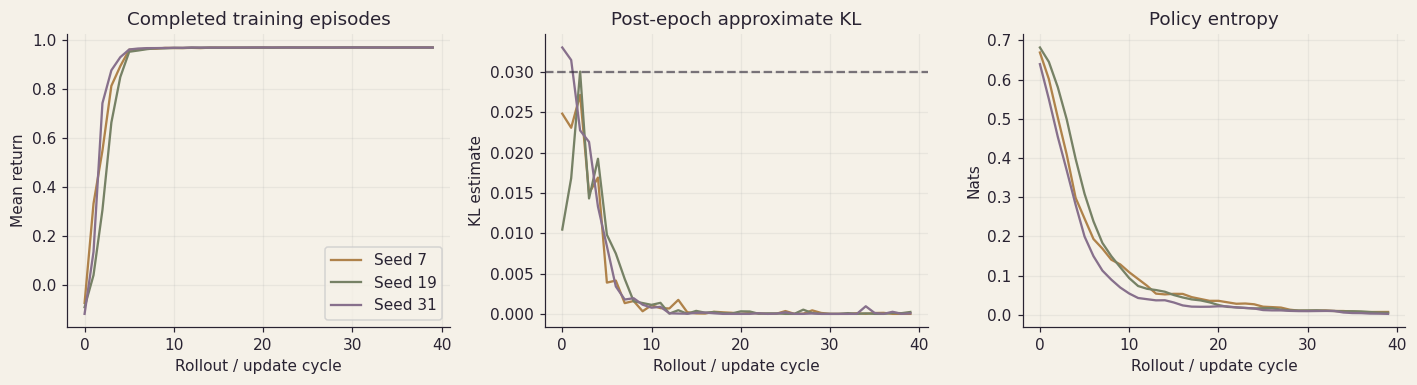

In [6]:
def evaluate(model, seed=2026, episodes=300):
    env = VectorCueCorridor(seed, n_envs=1)
    obs, total, totals, successes = env.observation(), 0.0, [], []
    with torch.random.fork_rng(), torch.no_grad():
        torch.manual_seed(seed + 1)
        while len(totals) < episodes:
            logits, _ = model(torch.from_numpy(obs))
            actions = Categorical(logits=logits).sample().numpy()
            obs, rewards, terminated, _, success = env.step(actions)
            total += float(rewards[0])
            if terminated[0]:
                totals.append(total); successes.append(success[0]); total = 0.0
    return np.mean(totals), np.mean(successes)

torch.manual_seed(123)
baseline = evaluate(ActorCritic())
scores = np.array([evaluate(model) for model, _, _ in runs])
print(f'Untrained policy: return {baseline[0]:.3f}, success {baseline[1]:.1%}')
for seed, score in zip(SEEDS, scores): print(f'PPO seed {seed}: return {score[0]:.3f}, success {score[1]:.1%}')
assert scores[:, 1].mean() > baseline[1]
assert all(np.isfinite(diagnostics).all() for _, _, diagnostics in runs)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for seed, (_, history, diagnostics) in zip(SEEDS, runs):
    axes[0].plot(history, label=f'Seed {seed}')
    axes[1].plot(diagnostics[:, 0])
    axes[2].plot(diagnostics[:, 2])
axes[0].set(title='Completed training episodes', ylabel='Mean return')
axes[1].set(title='Post-epoch approximate KL', ylabel='KL estimate')
axes[1].axhline(CONFIG.target_kl, ls='--', color=INK, alpha=0.6)
axes[2].set(title='Policy entropy', ylabel='Nats')
for ax in axes: ax.set_xlabel('Rollout / update cycle')
axes[0].legend(); plt.tight_layout(); plt.show()

Higher return and lower entropy are expected as this easy deterministic task is learned.
The approximate KL may exceed the threshold because the stopping check happens **after**
an epoch; the threshold prevents additional epochs rather than undoing the last update.
This compact implementation omits production conveniences such as observation normalization,
value clipping, continuous-action distributions, checkpointing, and distributed collection.
Its on-policy rollout and terminal-boundary logic are nevertheless complete for this task.

## Exercises

1. Set GAE lambda to 0 and 1. Compare learning across all seeds.
2. Double the number of minibatch epochs and inspect KL.
3. Remove the entropy bonus. Does the policy become deterministic sooner?
4. Add an external time limit shorter than 12 steps and implement both masks correctly.

<details>
<summary>Hints and expected reasoning — open after trying the exercises</summary>

1. Zero uses one-step TD; one uses all available residuals, retaining a final bootstrap for unfinished rollouts.
2. More reuse can cause larger distribution drift.
3. This easy task may not need much exploration after the cue is learned.
4. Save the last observation before reset, bootstrap it when not truly terminal, and stop advantage recursion at reset.

</details>

## What to remember

PPO depends on correct data bookkeeping: fixed old probabilities, fixed targets, correctly masked GAE, and fresh rollouts after each update phase.

## Further reading

- Schulman et al., [Proximal Policy Optimization Algorithms](https://arxiv.org/abs/1707.06347).
- Schulman et al., [Generalized Advantage Estimation](https://arxiv.org/abs/1506.02438).

[← Previous notebook](05_policy_gradient.ipynb) · [Next notebook →](07_preference_and_grpo.ipynb)